In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("store_customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


In [3]:
print("Shape of dataset:", df.shape)

Shape of dataset: (1000, 5)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    object 
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 39.2+ KB


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,1000.000000,994.000000,996.000000,994.000000
mean,1499.500000,38.935614,57.149096,42.645875
std,288.819436,13.399880,28.628506,20.101589
min,1000.000000,18.000000,15.000000,1.000000
25%,1249.750000,30.000000,34.975000,31.000000
50%,1499.500000,36.000000,49.000000,47.000000
75%,1749.250000,44.000000,79.400000,57.000000
max,1999.000000,80.000000,144.100000,92.000000


In [6]:
df.isnull().sum()

CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

In [8]:
df1 = df.dropna()

In [9]:
df1.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [11]:
print("Duplicate rows:", df1.duplicated().sum())

Duplicate rows: 0


In [13]:
X = df1[[
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,59.9,58.0
1,48.4,37.0
2,70.5,26.0
3,81.1,30.0
4,42.1,58.0


In [14]:
X.describe()

,Annual Income (k$),Spending Score (1-100)
count,982.000000,982.000000
mean,57.326782,42.603870
std,28.658961,20.121469
min,15.000000,1.000000
25%,35.125000,31.000000
50%,49.150000,47.000000
75%,79.475000,57.000000
max,144.100000,92.000000


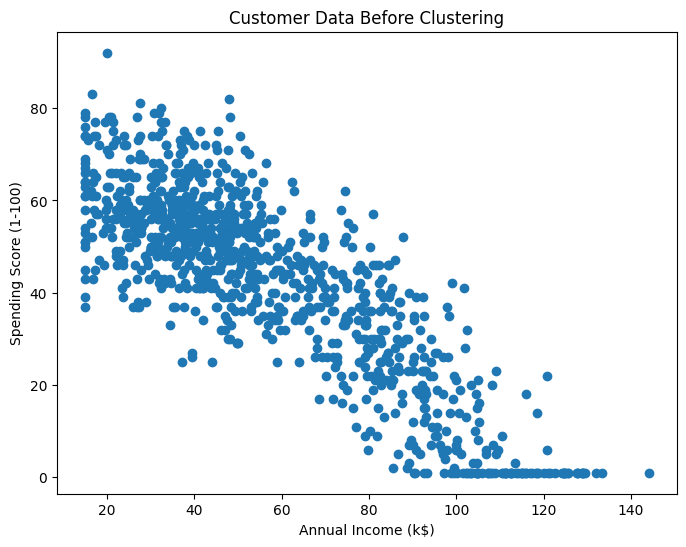

In [15]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"]
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Data Before Clustering")

plt.show()

In [16]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [17]:
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled_df.head()

,Annual Income (k$),Spending Score (1-100)
0,0.089833,0.765549
1,-0.311642,-0.278644
2,0.459889,-0.825602
3,0.829944,-0.626708
4,-0.531580,0.765549


In [18]:
inertia = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

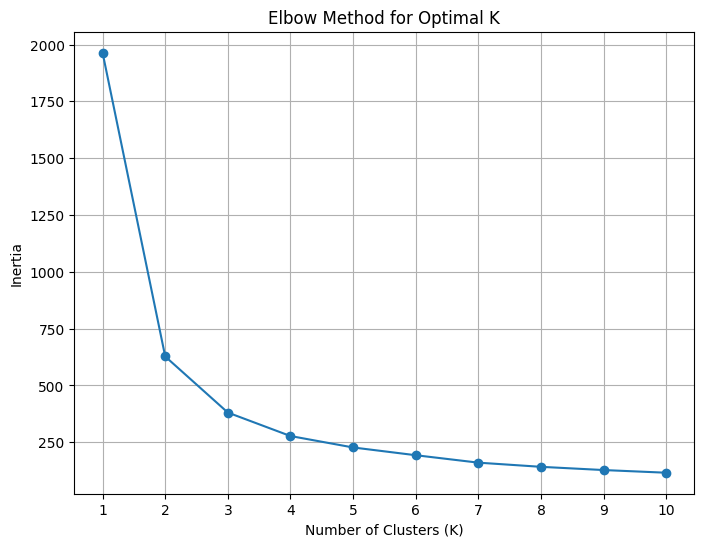

In [19]:
plt.figure(figsize=(8, 6))

plt.plot(
    range(1, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.xticks(range(1, 11))
plt.grid(True)

plt.show()

In [20]:
optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

In [23]:
df1["Cluster"] = clusters

df.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_19948\37599958.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["Cluster"] = clusters


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


In [25]:
df1["Cluster"].value_counts().sort_index()

Cluster
0    287
1    207
2    340
3    148
Name: count, dtype: int64

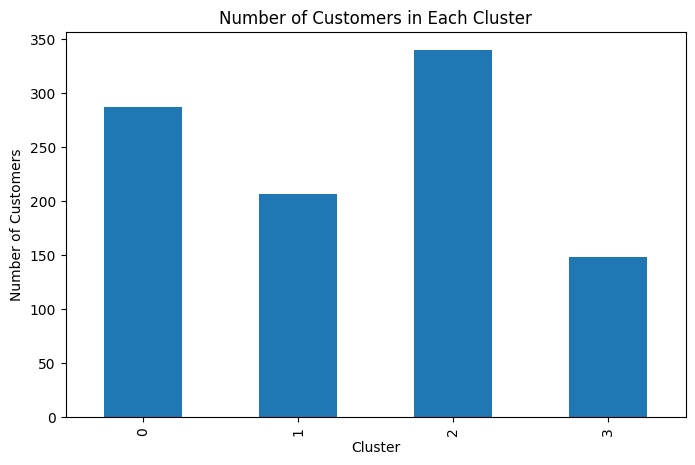

In [27]:
df1["Cluster"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Number of Customers in Each Cluster")

plt.show()

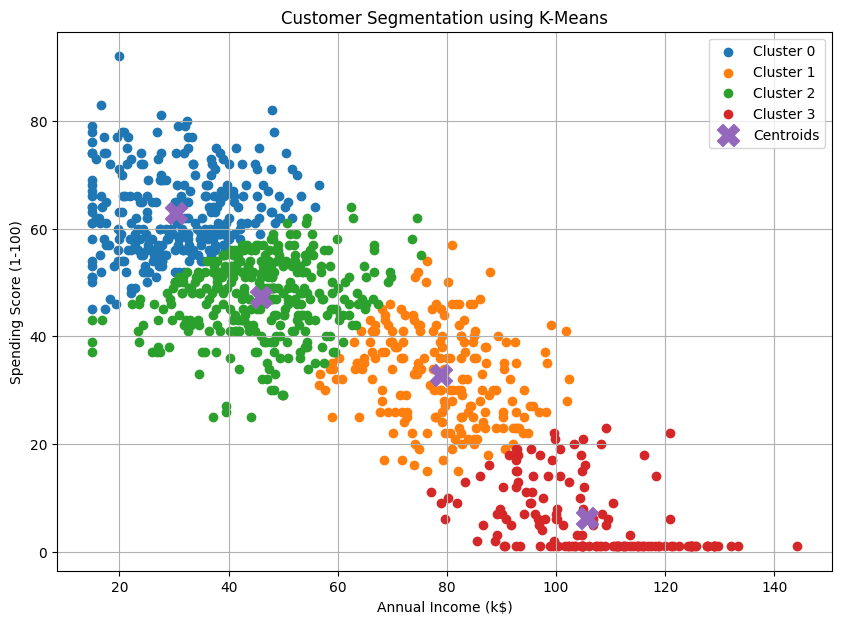

In [29]:
plt.figure(figsize=(10, 7))

for cluster in range(optimal_k):

    cluster_data = df1[df1["Cluster"] == cluster]

    plt.scatter(
        cluster_data["Annual Income (k$)"],
        cluster_data["Spending Score (1-100)"],
        label=f"Cluster {cluster}"
    )

# Get cluster centers in scaled space
centers_scaled = kmeans.cluster_centers_

# Convert centers back to original scale
centers = scaler.inverse_transform(centers_scaled)

# Plot centroids
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="X",
    s=250,
    label="Centroids"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation using K-Means")

plt.legend()
plt.grid(True)

plt.show()

In [31]:
cluster_analysis = df1.groupby("Cluster").agg({
    "Age": "mean",
    "Annual Income (k$)": "mean",
    "Spending Score (1-100)": "mean",
    "CustomerID": "count"
})

cluster_analysis

,Age,Annual Income (k$),Spending Score (1-100),CustomerID
Cluster,,,,
0,28.247387,30.393728,62.825784,287
1,44.212560,78.849758,32.845411,207
2,33.882353,45.938235,47.308824,340
3,64.040541,105.614865,6.229730,148


In [32]:
cluster_analysis = cluster_analysis.rename(
    columns={
        "CustomerID": "Customer Count"
    }
)

cluster_analysis

,Age,Annual Income (k$),Spending Score (1-100),Customer Count
Cluster,,,,
0,28.247387,30.393728,62.825784,287
1,44.212560,78.849758,32.845411,207
2,33.882353,45.938235,47.308824,340
3,64.040541,105.614865,6.229730,148


In [33]:
cluster_analysis.sort_values(
    "Spending Score (1-100)",
    ascending=False
)

,Age,Annual Income (k$),Spending Score (1-100),Customer Count
Cluster,,,,
0,28.247387,30.393728,62.825784,287
2,33.882353,45.938235,47.308824,340
1,44.212560,78.849758,32.845411,207
3,64.040541,105.614865,6.229730,148


In [35]:
gender_analysis = pd.crosstab(
    df1["Cluster"],
    df1["Gender"]
)

gender_analysis

Gender,F,M
Cluster,,
0,146,141
1,106,101
2,177,163
3,82,66


In [37]:
cluster_profile = df1.groupby("Cluster").agg(
    Customers=("CustomerID", "count"),
    Average_Age=("Age", "mean"),
    Average_Income=("Annual Income (k$)", "mean"),
    Average_Spending=("Spending Score (1-100)", "mean")
)

cluster_profile.round(2)

,Customers,Average_Age,Average_Income,Average_Spending
Cluster,,,,
0,287,28.25,30.39,62.83
1,207,44.21,78.85,32.85
2,340,33.88,45.94,47.31
3,148,64.04,105.61,6.23


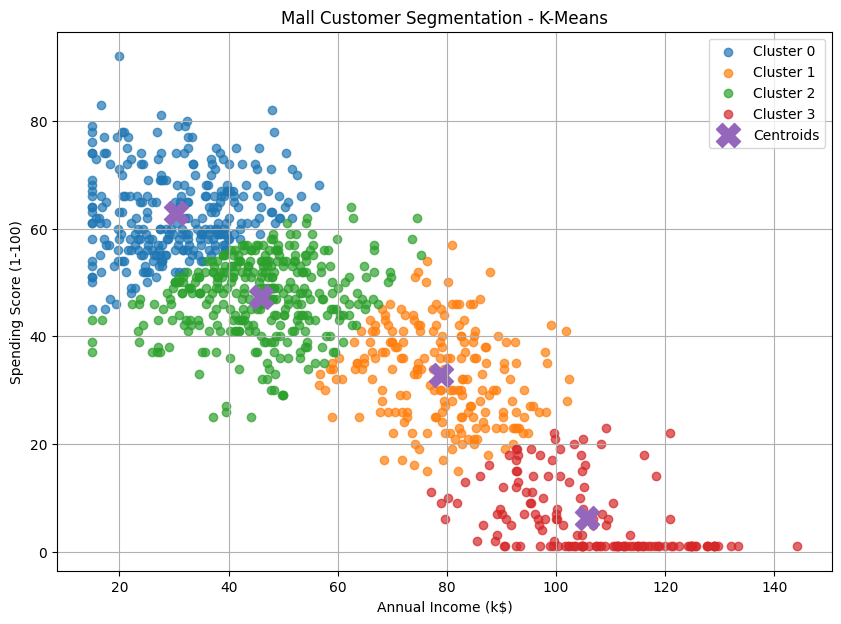

In [39]:
plt.figure(figsize=(10, 7))

for cluster in range(optimal_k):

    cluster_data = df1[df1["Cluster"] == cluster]

    plt.scatter(
        cluster_data["Annual Income (k$)"],
        cluster_data["Spending Score (1-100)"],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="X",
    s=300,
    label="Centroids"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Mall Customer Segmentation - K-Means")

plt.legend()
plt.grid(True)

plt.show()

In [40]:
df.to_csv(
    "store_customers_clustered.csv",
    index=False
)